# Algorytmy Macierzowe — operacje na macierzach hierarchicznych

### Krzysztof Kopel, Marcin Szulc

## Cel laboratorium
Celem laboratorium było zapoznanie się z operacjami na macierzach hierarchicznych (skompresowanych), w szczególności z:
- mnożeniem macierzy skompresowanej przez wektor
- dodawaniem dwóch macierzy skompresowanych
- mnożeniem dwóch macierzy skompresowanych
Poza implementacją wymienionych algorytmów, naszym zadaniem było także przeprowadzenie analizy ich złożoności obliczeniowej w sposób eksperymentalny, oraz oszacowanie błędu, jaki popełniamy w porównaniu do operacji na macierzach nieskompresowanych.

## Ustalenia techniczne
Do realizacji zadań w ramach laboratorium użyliśmy języka Python w wersji 3.12. Macierze zapisywaliśmy jako NumPy nd-arrays. Nie implementowaliśmy własnego SVD, zamiast tego wykorzystaliśmy wersję dostępną w bibliotece SciPy. Wykorzystaliśmy algorytm kompresji i rysowacze z poprzedniego laboratorium.

## Zastosowane algorytmy
### Mnożenie macierzy hierarchicznej przez wektor
Algorytm wykorzystuje strukturę drzewa, jaką zastosowaliśmy przy kompresji macierzy. Można opisać go następujacym pseudokodem (dla węzła drzewa *v* i wektora *X*):
1. Jeśli dany węzeł drzewa jest liściem, sprawdź, czy jego rank wynosi 0 - jeśli tak, zwróć macierz z samymi zerami, a jeśli nie, zwróć $v.U * (v.V * X)$, gdzie $v.U$ i $v.V$ to odpowiednie wektory zwrócone przez SVD.
2. Jeśli dany węzeł nie jest liściem (czyli ma dzieci, nazwane tutaj $v_1$ do $v_4$), podziel wektor na dwie części ($X_1$ i $X_2$) i pomnóż według poniższego schematu:
$$
\begin{bmatrix}
v_{11} & v_{12}\\
v_{21} & v_{22}\\
\end{bmatrix}
\begin{bmatrix}
X_1 \\
X_2 \\
\end{bmatrix}
=
\begin{bmatrix}
Y_1^{(1)} + Y_1^{(2)}\\
Y_2^{(1)} + Y_2^{(2)}\\
\end{bmatrix}
$$

gdzie:
- $Y_1^{(1)}$ = matrix_vector_mult($v_1$, $X_1$)
- $Y_1^{(2)}$ = matrix_vector_mult($v_2$, $X_2$)
- $Y_2^{(1)}$ = matrix_vector_mult($v_3$, $X_1$)
- $Y_2^{(2)}$ = matrix_vector_mult($v_4$, $X_2$)

Powyższy algorytm może mieć (dla rank-1) złożoność $O(n log(n))$, ponieważ drzewo ma $log(n)$ pięter, a każde piętro wymaga wykonania liniowej liczby operacji (ponieważ mnożenie wektorów jest liniowe).

Poniżej prezentujemy najważniejszy fragment kodu:
```Python
def matrix_vector_mult(treeNode: TreeNode, vector: np.ndarray) -> np.ndarray:
    if not treeNode.children:
        if treeNode.rank == 0:
            return np.zeros(treeNode.matrix.shape[0], dtype=vector.dtype)
        return treeNode.svd.U @ (treeNode.svd.V @ vector)

    rows = treeNode.matrix.shape[0]
    X1 = vector[:rows // 2]
    X2 = vector[rows // 2:]

    Y1 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[0], X1)
    Y2 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[1], X2)
    Y3 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[2], X1)
    Y4 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[3], X2)

    return np.vstack((Y1 + Y2, Y3 + Y4))
```
### Dodawanie macierzy skompresowanych
**TODO**
### Mnożenie macierzy skompresowanych
**TODO**

## Generowanie przykładowych macierzy
Zgodnie z poleceniem wygenerowaliśmy w celach testowych przykładowe macierze o rozmiarach postaci $2^{3k}$ x $2^{3k}$, dla $k \in \{2, 3, 4\}$. Wygenerowaliśmy po dwie macierze każdego z tych rozmiarów (aby móc je przez siebie mnożyć) i dodatkowo po jednym wektorze o odpowiednim rozmiarze postaci $2^{3k}$ x $1$, dla tych samych wartości $k$.

In [1]:
import numpy as np

from CompressedMatrixOperations import CompressedMatrixOperations

example_matrices = []
for k in [2, 3, 4]:
    matrix_a = np.random.rand(2 ** (3 * k), 2 ** (3 * k))
    vector = np.random.rand(2 ** (3 * k), 1)
    example_matrices.append((matrix_a, vector))

Następnie, poddaliśmy wszystkie macierze rekurencyjnej kompresji, wykorzystując do tego celu algorytm z poprzedniego laboratorium. Jako epsilon dla macierzy o rozmiarze $n$ podaliśmy wartość osobliwą nr $\frac{n}{8}$ — dzięki temu uzyskaliśmy kompormis między szybkością działania algorytmu a jakością kompresji. Zapamiętujemy jeden wiersz i jedną kolumnę z macierzy wyjściowych SVD — stąd rank 1.

In [2]:
from TreeNode import TreeNode

matrices_compressed = []
for matrix_a, vector in example_matrices:
    _, sing_values_a, _ = np.linalg.svd(matrix_a)
    matrix_a_comp = TreeNode(1, (0, 0, matrix_a.shape[0], matrix_a.shape[1]), matrix_a)
    matrix_a_comp.compress_matrix(sing_values_a[len(sing_values_a) // 8])

    matrices_compressed.append((matrix_a_comp, vector))

Poniżej przedstawiamy największą macierz w postaci skompresowanej — zarówno w wersji z kwadratami, jak i (w zasadzie jako ciekawostka) jako bitmapę, stosując tym bardziej "szarą" kolorystykę, im większa była dana wartość po kompresji.

Text(0.5, 0.98, 'Wizualizacja macierzy 4096 x 4096 po kompresji')

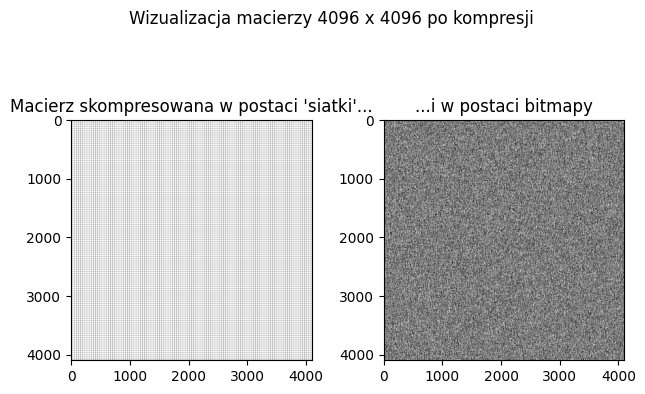

In [3]:
import matplotlib.pyplot as plt

matrix_a = matrices_compressed[-1][0]
fig, ax = plt.subplots(1, 2)
ax[0].imshow(matrix_a.create_structure_image(), cmap="gray")
ax[0].set_title("Macierz skompresowana w postaci 'siatki'...")

ax[1].imshow(matrix_a.reconstruct_image(), cmap="gray")
ax[1].set_title("...i w postaci bitmapy")

fig.tight_layout()
fig.suptitle("Wizualizacja macierzy 4096 x 4096 po kompresji")

Na lewym obrazku widzimy serię dość równomiernie rozłożonych, małych kwadratów. Niektóre z nich wydają się większe — to prawdopodobnie te macierze, które w wyniku kolejnych podziałów szybciej zeszły do postaci możliwej do przedstawienia jako iloczyn dwóch wektorów.

Ciekawy jest także wygląd prawego obrazka — przypomina on trochę obraz wyświetlany przez stare telewizory, gdy ustawiło się je na nieistniejący kanał. Pokazuje to, że taka losowo wygenerowana macierz nie zawiera w sobie żadnego "obrazu", który można by odróżnić gołym okiem.

Jednocześnie odpalenie rysowacza uświadomiło nam, że w tym przypadku nie ma za bardzo sensu dalsze wizualizowanie wyników naszych eksperymentów w taki sposób, jak robiliśmy to przy okazji poprzedniego laboratorium. Skoro nie korzystamy tutaj z bitmapy, a z macierzy wartości losowych, to nie dostaniemy "widzialnych" rezultatów.

## Test algorytmu mnożenia macierzy skompresowanej przez wektor

In [4]:
from time import perf_counter
from CompressedMatrixOperations import CompressedMatrixOperations

# Kluczami w tym słowniku są kolejne wartości
times = {2: [], 3: [], 4: []}

for _ in range(4):
    for matrix_a, vector in matrices_compressed:
        start_time = perf_counter()
        CompressedMatrixOperations.matrix_vector_mult(matrix_a, vector)
        end_time = perf_counter()
        times[np.log2(vector.shape[0]) // 3].append(end_time - start_time)

times = {2 ** (3 * k): np.median(v) for (k, v) in times.items()}

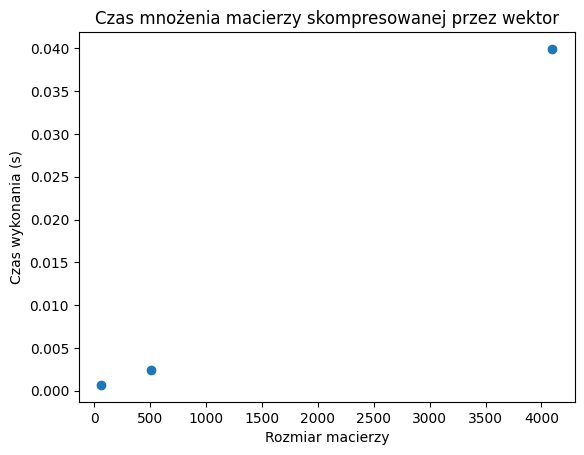

In [5]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez wektor")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

Zgodnie z poleceniem, do wykresu zależności czasu wykonania od rozmiaru macierzy dopasowaliśmy numerycznie krzywą postaci $$f(N) = \alpha N ^ {\beta}$$

In [6]:
def fun(n, alpha, beta):
    return alpha * (n ** beta)

from scipy.optimize import curve_fit

params, _ = curve_fit(fun, list(times.keys()), list(times.values()))

In [7]:
print(f"Optymalne wartości:\n alpha={params[0]}\n beta={params[1]}")

Optymalne wartości:
 alpha=6.362811459622129e-07
 beta=1.328134584767445


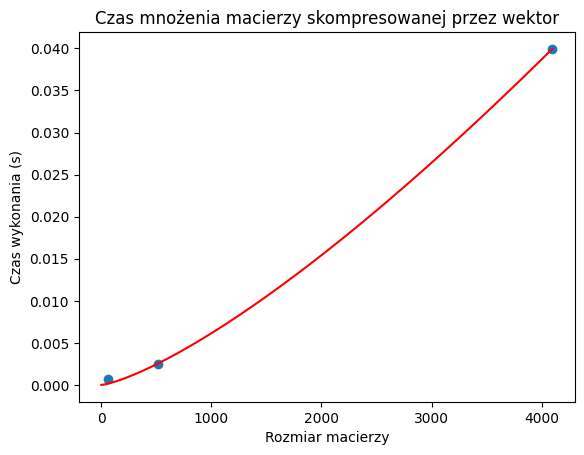

In [8]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez wektor")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.plot(range(1, 4097), [fun(i, params[0], params[1]) for i in range(1, 4097)], color="red")
plt.show()

Na potrzeby naszej analizy najważniejszy jest parametr $\beta$, więc to na nim się skupimy: widzimy, że przybrał on wartość $\approx 1.3$. Oznacza to, że algorytm ma złożoność nieco gorszą od liniowej ($\beta = 1$), ale dużo lepszą od kwadratowej ($\beta = 2$). Może to oznaczać, że estymacja złożoności teoretycznej $O(n log(n))$ jest prawidłowa.

### Porównanie z wynikiem uzyskanym bez kompresji
Do obliczenia normy Frobeniusa wykorzystaliśmy funkcję obliczającą tę normę, dostępną w bibliotece NumPy

Normę policzyliśmy dla największej macierzy.

In [9]:
correct_result = example_matrices[-1][0] @ example_matrices[-1][1]
our_result = CompressedMatrixOperations.matrix_vector_mult(matrices_compressed[-1][0], matrices_compressed[-1][1])

print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 61308.32020530512
Suma kwadratów macierzy będącej naszym rezultatem = 4043.848700435246


Widzimy, że dostaliśmy stosunkowo sporą wartość. Spróbujmy wywołać algorytm dla mniejszej macierzy, ale dużo lepiej skompresowanej.

In [10]:
_, sing_values_a, _ = np.linalg.svd( example_matrices[0][0])

compressed_small = TreeNode(1, (0, 0, example_matrices[0][0].shape[0], example_matrices[0][0].shape[1]), example_matrices[0][0])
compressed_small.compress_matrix(sing_values_a[-1])
correct_result = example_matrices[0][0] @ example_matrices[0][1]
our_result = CompressedMatrixOperations.matrix_vector_mult(compressed_small, example_matrices[0][1])

print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 113.62140396214264
Suma kwadratów macierzy będącej naszym rezultatem = 222.4020028121005


Widzimy, że jest dużo lepiej! Macierze faktycznie są znacznie bardziej podobne, co pokazuje, że wyższy stopień kompresji faktycznie pomógł uzyskać bardizej precyzyjny wynik.

In [11]:
our_result

array([[27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27.80025035],
       [27

In [12]:
correct_result

array([[13.85570497],
       [13.170003  ],
       [13.71527317],
       [13.75970123],
       [14.9381047 ],
       [12.29234476],
       [13.41899693],
       [12.47661644],
       [15.48811363],
       [12.93208553],
       [13.41315147],
       [13.9001914 ],
       [13.26392665],
       [13.62745927],
       [13.523241  ],
       [13.65623083],
       [11.67607897],
       [12.95605174],
       [14.80303553],
       [14.02708142],
       [13.6769561 ],
       [14.99483123],
       [13.52333312],
       [13.99165322],
       [16.01891683],
       [13.1734266 ],
       [14.00389688],
       [12.79682861],
       [10.93994867],
       [12.91691374],
       [12.21058304],
       [11.48086137],
       [14.79892611],
       [15.50340654],
       [12.10750482],
       [15.70412613],
       [13.30807853],
       [15.57131705],
       [14.07457656],
       [14.04959609],
       [15.24602936],
       [14.70489315],
       [14.17590354],
       [14.6684605 ],
       [14.13923097],
       [14

## Test algorytmu mnożenia macierzy skompresowanej przez macierz skompresowaną

In [ ]:
# Kluczami w tym słowniku są kolejne wartości
times = {2: [], 3: [], 4: []}

for _ in range(4):
    for matrix_a, _ in matrices_compressed:
        start_time = perf_counter()
        CompressedMatrixOperations.matrix_matrix_mult(matrix_a, matrix_a)
        end_time = perf_counter()
        times[np.log2(vector.shape[0]) // 3].append(end_time - start_time)

times = {2 ** (3 * k): np.median(v) for (k, v) in times.items()}

/home/mszulc/AGH/MACIERZOWE/AlgoMacierzowe/matrix-venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mszulc/AGH/MACIERZOWE/AlgoMacierzowe/matrix-venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez samą siebie")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()